## 1. Install Dependencies


In [2]:
import sys
!{sys.executable} -m pip install --user librosa==0.11.0 scikit-learn tqdm numpy pandas matplotlib seaborn --quiet



[notice] A new release of pip available: 22.3.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


## 2. Imports and Setup


In [3]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import librosa
import librosa.display
import pickle
import warnings
warnings.filterwarnings('ignore')

from tqdm import tqdm
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

SR      = 22050
N_MELS  = 128
N_FFT   = 2048
HOP_LEN = 512
FMIN    = 20
FMAX    = 8000
N_MFCC  = 40

N_AUGMENT = 3      # copias ruidosas por archivo de train
NOISE_STD = 0.005  # std del ruido gaussiano (~0.5% de la amplitud)

CLASSES = [
    'bus', 'busystreet', 'office', 'openairmarket', 'park',
    'quietstreet', 'restaurant', 'supermarket', 'tube', 'tubestation'
]
CLASS_TO_IDX = {cls: idx for idx, cls in enumerate(CLASSES)}

OUTPUT_DIR = 'output_block2'
os.makedirs(OUTPUT_DIR, exist_ok=True)

print('Setup complete.')
print(f'Augmentation : Gaussian noise, std={NOISE_STD}, N_AUGMENT={N_AUGMENT}')
print(f'Expected train samples: 80 original + {80*N_AUGMENT} augmented = {80*(1+N_AUGMENT)}')


Setup complete.
Augmentation : Gaussian noise, std=0.005, N_AUGMENT=3
Expected train samples: 80 original + 240 augmented = 320


## 3. Load Annotations 




In [5]:
csv_path = os.path.join(OUTPUT_DIR, 'dcase2013_annotations.csv')
df = pd.read_csv(csv_path)

print(f'Annotations loaded: {len(df)} files')
print(df.head())



Annotations loaded: 100 files
    filename                                           filepath label  \
0  bus01.wav  C:\Users\34610\Desktop\UNIVERSIDAD\Máster\Inte...   bus   
1  bus02.wav  C:\Users\34610\Desktop\UNIVERSIDAD\Máster\Inte...   bus   
2  bus03.wav  C:\Users\34610\Desktop\UNIVERSIDAD\Máster\Inte...   bus   
3  bus04.wav  C:\Users\34610\Desktop\UNIVERSIDAD\Máster\Inte...   bus   
4  bus05.wav  C:\Users\34610\Desktop\UNIVERSIDAD\Máster\Inte...   bus   

   label_idx  
0          0  
1          0  
2          0  
3          0  
4          0  


## 4. Train / Validation Split 


In [6]:
df_train_files, df_val_files = train_test_split(
    df,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=df['label_idx']
)

df_train_files = df_train_files.reset_index(drop=True)
df_val_files   = df_val_files.reset_index(drop=True)

print(f'Train files : {len(df_train_files)} — dist: {np.bincount(df_train_files["label_idx"].values)}')
print(f'Val files   : {len(df_val_files)}   — dist: {np.bincount(df_val_files["label_idx"].values)}')


Train files : 80 — dist: [8 8 8 8 8 8 8 8 8 8]
Val files   : 20   — dist: [2 2 2 2 2 2 2 2 2 2]


## 5. Preprocessing and Augmentation Functions

### Gaussian Noise Augmentation



In [7]:
def preprocess_audio(filepath, sr=SR):
    """Load, resample, convert to mono and peak-normalize."""
    wav, _ = librosa.load(filepath, sr=sr, mono=True)
    return wav / (np.max(np.abs(wav)) + 1e-9)


def add_gaussian_noise(wav, noise_std=NOISE_STD):
    """
    Add Gaussian noise to a waveform.
    wav must be peak-normalized to [-1, 1].
    Returns noisy waveform clipped to [-1, 1].
    """
    noise = np.random.normal(0, noise_std, wav.shape)
    return np.clip(wav + noise, -1.0, 1.0)


def extract_logmel_features(wav, sr=SR):
    """Log-Mel statistical features (mean + std). Returns 256-dim vector."""
    mel = librosa.feature.melspectrogram(
        y=wav, sr=sr, n_mels=N_MELS, n_fft=N_FFT,
        hop_length=HOP_LEN, fmin=FMIN, fmax=FMAX
    )
    log_mel = librosa.power_to_db(mel, ref=np.max)
    return np.concatenate([np.mean(log_mel, axis=1), np.std(log_mel, axis=1)])


def extract_mfcc_features(wav, sr=SR):
    """MFCC statistical features (mean + std). Returns 80-dim vector."""
    mfcc = librosa.feature.mfcc(
        y=wav, sr=sr, n_mfcc=N_MFCC, n_fft=N_FFT,
        hop_length=HOP_LEN, fmin=FMIN, fmax=FMAX
    )
    return np.concatenate([np.mean(mfcc, axis=1), np.std(mfcc, axis=1)])


print('Functions defined.')
print(f'Noise std: {NOISE_STD} (~{NOISE_STD*100:.1f}% of signal amplitude)')


Functions defined.
Noise std: 0.005 (~0.5% of signal amplitude)


## 6. Visualize Augmentation Effect




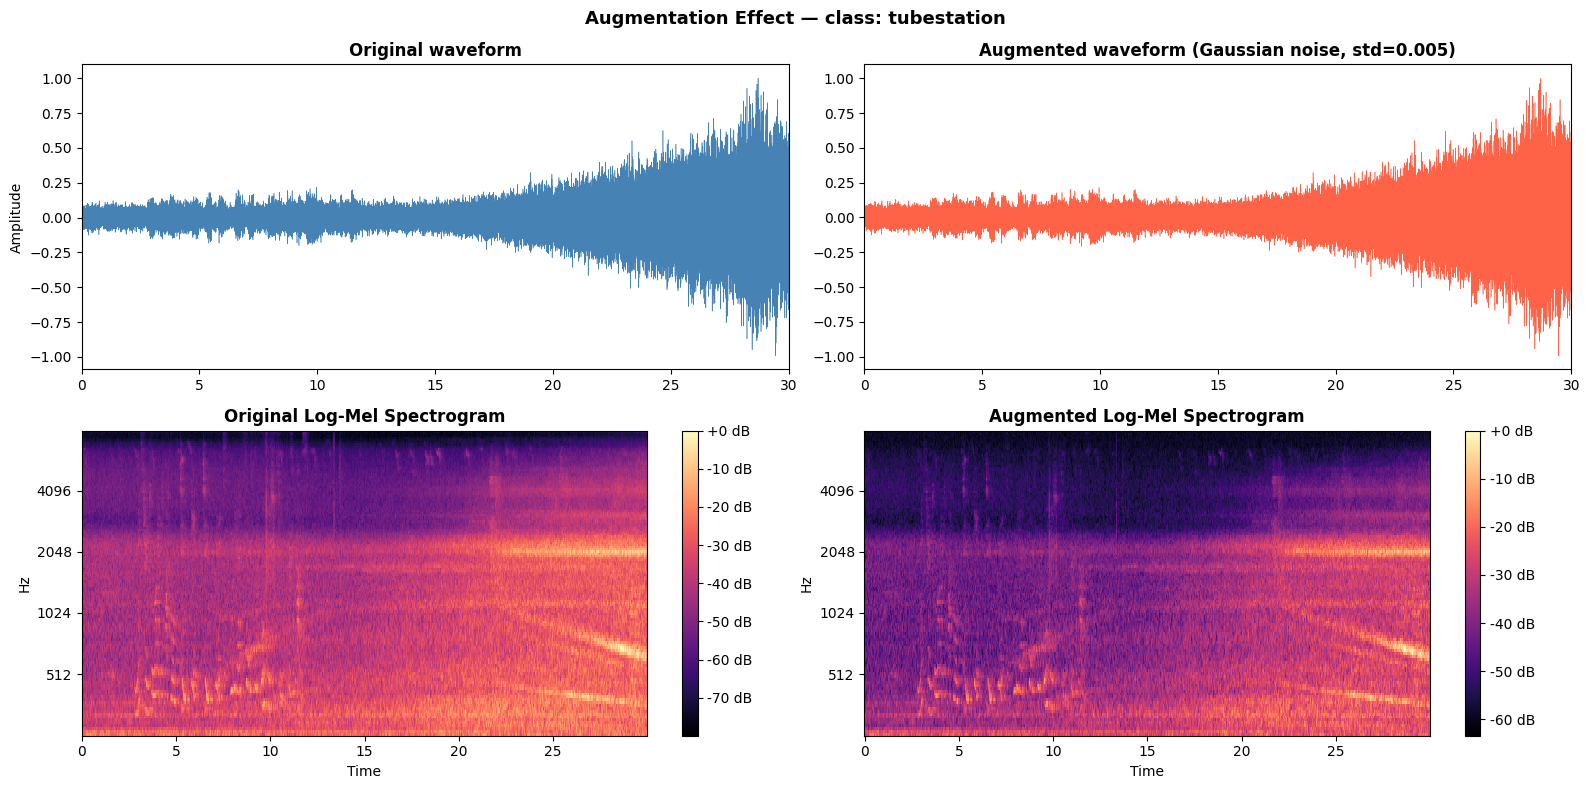

Saved: output_block2\augmentation_effect.png
Max waveform difference : 0.024147
Mean waveform difference: 0.003994
Spectrogram diff (mean) : 1.2857 dB


In [8]:
example_path  = df_train_files.iloc[0]['filepath']
example_label = df_train_files.iloc[0]['label']
wav_orig = preprocess_audio(example_path)
wav_aug  = add_gaussian_noise(wav_orig)

def get_logmel(wav):
    mel = librosa.feature.melspectrogram(
        y=wav, sr=SR, n_mels=N_MELS, n_fft=N_FFT,
        hop_length=HOP_LEN, fmin=FMIN, fmax=FMAX
    )
    return librosa.power_to_db(mel, ref=np.max)

spec_orig = get_logmel(wav_orig)
spec_aug  = get_logmel(wav_aug)

fig, axes = plt.subplots(2, 2, figsize=(16, 8))
fig.suptitle(f'Augmentation Effect — class: {example_label}',
             fontsize=13, fontweight='bold')

time_axis = np.linspace(0, len(wav_orig)/SR, len(wav_orig))

axes[0,0].plot(time_axis, wav_orig, color='steelblue', linewidth=0.4)
axes[0,0].set_title('Original waveform', fontweight='bold')
axes[0,0].set_ylabel('Amplitude')
axes[0,0].set_xlim([0, 30])

axes[0,1].plot(time_axis, wav_aug, color='tomato', linewidth=0.4)
axes[0,1].set_title(f'Augmented waveform (Gaussian noise, std={NOISE_STD})', fontweight='bold')
axes[0,1].set_xlim([0, 30])

img1 = librosa.display.specshow(
    spec_orig, sr=SR, hop_length=HOP_LEN,
    x_axis='time', y_axis='mel', fmin=FMIN, fmax=FMAX,
    ax=axes[1,0], cmap='magma'
)
axes[1,0].set_title('Original Log-Mel Spectrogram', fontweight='bold')
fig.colorbar(img1, ax=axes[1,0], format='%+2.0f dB')

img2 = librosa.display.specshow(
    spec_aug, sr=SR, hop_length=HOP_LEN,
    x_axis='time', y_axis='mel', fmin=FMIN, fmax=FMAX,
    ax=axes[1,1], cmap='magma'
)
axes[1,1].set_title('Augmented Log-Mel Spectrogram', fontweight='bold')
fig.colorbar(img2, ax=axes[1,1], format='%+2.0f dB')

plt.tight_layout()
out_path = os.path.join(OUTPUT_DIR, 'augmentation_effect.png')
plt.savefig(out_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {out_path}')
print(f'Max waveform difference : {np.max(np.abs(wav_aug - wav_orig)):.6f}')
print(f'Mean waveform difference: {np.mean(np.abs(wav_aug - wav_orig)):.6f}')
print(f'Spectrogram diff (mean) : {np.mean(np.abs(spec_aug - spec_orig)):.4f} dB')


## 7. Extract Features with Augmentation (Train Set)



In [ ]:
def extract_features_with_augmentation(df_files, augment=True, n_augment=N_AUGMENT):
    """
    Extraer features Log-Mel y MFCC de todos los archivos del DataFrame.
    Si augment=True, se genera n_augment copias ruidosas adicionales por archivo.
    Si augment=False, extrae solo el original (para val/test).
    """
    X_logmel, X_mfcc, y, sources = [], [], [], []

    for _, row in tqdm(df_files.iterrows(), total=len(df_files),
                       desc='Extracting features'):
        wav   = preprocess_audio(row['filepath'])
        label = row['label_idx']

        # Original
        X_logmel.append(extract_logmel_features(wav))
        X_mfcc.append(extract_mfcc_features(wav))
        y.append(label)
        sources.append('original')

        # Augmented copies (solo train)
        if augment:
            for _ in range(n_augment):
                wav_aug = add_gaussian_noise(wav)
                X_logmel.append(extract_logmel_features(wav_aug))
                X_mfcc.append(extract_mfcc_features(wav_aug))
                y.append(label)
                sources.append('augmented')

    return np.array(X_logmel), np.array(X_mfcc), np.array(y), sources


print('Extracting TRAIN features (original + augmented)...')
X_logmel_train, X_mfcc_train, y_train, sources_train = extract_features_with_augmentation(
    df_train_files, augment=True
)

print('\nExtracting VAL features (original only)...')
X_logmel_val, X_mfcc_val, y_val, sources_val = extract_features_with_augmentation(
    df_val_files, augment=False
)

print(f'\nExtraction complete.')
print(f'X_logmel_train : {X_logmel_train.shape}  (expected: 320 × 256)')
print(f'X_mfcc_train   : {X_mfcc_train.shape}   (expected: 320 × 80)')
print(f'X_logmel_val   : {X_logmel_val.shape}   (expected: 20 × 256)')
print(f'X_mfcc_val     : {X_mfcc_val.shape}    (expected: 20 × 80)')
print(f'y_train dist   : {np.bincount(y_train)}  (expected: 32 per class)')
print(f'Sources        : {pd.Series(sources_train).value_counts().to_dict()}')


Extracting TRAIN features (original + augmented)...


Extracting features: 100%|██████████| 80/80 [02:15<00:00,  1.69s/it]



Extracting VAL features (original only)...


Extracting features: 100%|██████████| 20/20 [00:08<00:00,  2.40it/s]


Extraction complete.
X_logmel_train : (320, 256)  (expected: 320 × 256)
X_mfcc_train   : (320, 80)   (expected: 320 × 80)
X_logmel_val   : (20, 256)   (expected: 20 × 256)
X_mfcc_val     : (20, 80)    (expected: 20 × 80)
y_train dist   : [32 32 32 32 32 32 32 32 32 32]  (expected: 32 per class)
Sources        : {'augmented': 240, 'original': 80}


## 8. Verify Augmentation 




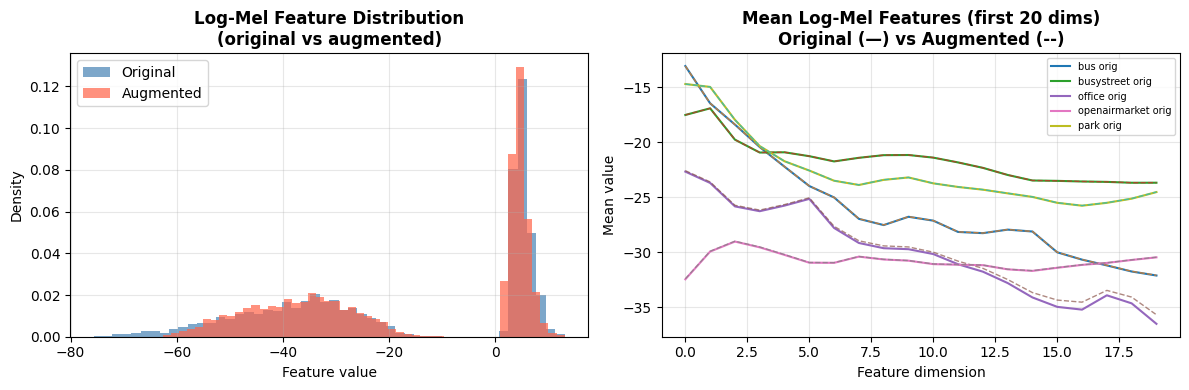

Saved: output_block2\augmentation_feature_distribution.png
Original  — mean: -16.8809, std: 23.6767
Augmented — mean: -16.4606, std: 22.3241


In [10]:
orig_mask = np.array(sources_train) == 'original'
aug_mask  = np.array(sources_train) == 'augmented'

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(X_logmel_train[orig_mask].flatten(), bins=50,
             alpha=0.7, color='steelblue', label='Original', density=True)
axes[0].hist(X_logmel_train[aug_mask].flatten(), bins=50,
             alpha=0.7, color='tomato', label='Augmented', density=True)
axes[0].set_title('Log-Mel Feature Distribution\n(original vs augmented)', fontweight='bold')
axes[0].set_xlabel('Feature value')
axes[0].set_ylabel('Density')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

for cls_idx, cls in enumerate(CLASSES[:5]):
    orig_cls = X_logmel_train[orig_mask & (y_train == cls_idx)]
    aug_cls  = X_logmel_train[aug_mask  & (y_train == cls_idx)]
    if len(orig_cls) > 0 and len(aug_cls) > 0:
        axes[1].plot(orig_cls.mean(axis=0)[:20], linestyle='-',  linewidth=1.5, label=f'{cls} orig')
        axes[1].plot(aug_cls.mean(axis=0)[:20],  linestyle='--', linewidth=1,   alpha=0.7)

axes[1].set_title('Mean Log-Mel Features (first 20 dims)\nOriginal (—) vs Augmented (--)',
                  fontweight='bold')
axes[1].set_xlabel('Feature dimension')
axes[1].set_ylabel('Mean value')
axes[1].legend(fontsize=7)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
out_path = os.path.join(OUTPUT_DIR, 'augmentation_feature_distribution.png')
plt.savefig(out_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {out_path}')
print(f'Original  — mean: {X_logmel_train[orig_mask].mean():.4f}, std: {X_logmel_train[orig_mask].std():.4f}')
print(f'Augmented — mean: {X_logmel_train[aug_mask].mean():.4f}, std: {X_logmel_train[aug_mask].std():.4f}')


## 9. Normalize Features



In [11]:
scaler_logmel = StandardScaler()
X_logmel_train_sc = scaler_logmel.fit_transform(X_logmel_train)
X_logmel_val_sc   = scaler_logmel.transform(X_logmel_val)

scaler_mfcc = StandardScaler()
X_mfcc_train_sc = scaler_mfcc.fit_transform(X_mfcc_train)
X_mfcc_val_sc   = scaler_mfcc.transform(X_mfcc_val)

print('Normalization applied (fit on augmented train, transform on val).')
print(f'Log-Mel train — mean: {X_logmel_train_sc.mean():.4f}, std: {X_logmel_train_sc.std():.4f}')
print(f'MFCC train    — mean: {X_mfcc_train_sc.mean():.4f}, std: {X_mfcc_train_sc.std():.4f}')


Normalization applied (fit on augmented train, transform on val).
Log-Mel train — mean: 0.0000, std: 1.0000
MFCC train    — mean: 0.0000, std: 1.0000


## 10. Save All Features and Scalers


In [12]:
np.savez(
    os.path.join(OUTPUT_DIR, 'features_logmel_aug.npz'),
    X_train=X_logmel_train_sc,
    X_val=X_logmel_val_sc,
    y_train=y_train,
    y_val=y_val,
    X_train_raw=X_logmel_train,
    X_val_raw=X_logmel_val
)

np.savez(
    os.path.join(OUTPUT_DIR, 'features_mfcc_aug.npz'),
    X_train=X_mfcc_train_sc,
    X_val=X_mfcc_val_sc,
    y_train=y_train,
    y_val=y_val
)

with open(os.path.join(OUTPUT_DIR, 'scaler_logmel_aug.pkl'), 'wb') as f:
    pickle.dump(scaler_logmel, f)

with open(os.path.join(OUTPUT_DIR, 'scaler_mfcc_aug.pkl'), 'wb') as f:
    pickle.dump(scaler_mfcc, f)

df_train_files.to_csv(os.path.join(OUTPUT_DIR, 'train_files_aug.csv'), index=False)
df_val_files.to_csv(os.path.join(OUTPUT_DIR, 'val_files_aug.csv'),   index=False)

print(f'All files saved to {OUTPUT_DIR}/')
print('  features_logmel_aug.npz  — augmented Log-Mel train/val')
print('  features_mfcc_aug.npz    — augmented MFCC train/val')
print('  scaler_logmel_aug.pkl    — Log-Mel scaler (fit on augmented train)')
print('  scaler_mfcc_aug.pkl      — MFCC scaler (fit on augmented train)')
print('  train_files_aug.csv      — train file list para Block 4 CNN')
print('  val_files_aug.csv        — val file list para Block 4 CNN')


All files saved to output_block2/
  features_logmel_aug.npz  — augmented Log-Mel train/val
  features_mfcc_aug.npz    — augmented MFCC train/val
  scaler_logmel_aug.pkl    — Log-Mel scaler (fit on augmented train)
  scaler_mfcc_aug.pkl      — MFCC scaler (fit on augmented train)
  train_files_aug.csv      — train file list para Block 4 CNN
  val_files_aug.csv        — val file list para Block 4 CNN


## 11. Dataset Summary


In [13]:
print('=' * 60)
print('BLOCK 2 (AUGMENTED) — SUMMARY')
print('=' * 60)
print()
print('AUGMENTATION')
print(f'  Technique          : Gaussian noise')
print(f'  Noise std          : {NOISE_STD} (~{NOISE_STD*100:.1f}% amplitude)')
print(f'  Copies per file    : {N_AUGMENT}')
print(f'  Applied to         : Train set ONLY')
print()
print('DATASET SIZES')
print(f'  Original train     : 80 files')
print(f'  Augmented train    : {80 * N_AUGMENT} files')
print(f'  Total train        : {80 * (1 + N_AUGMENT)} samples')
print(f'  Validation         : 20 samples (no augmentation)')
print(f'  Test               : 100 files (official, untouched)')
print()
print('FEATURE DIMENSIONS')
print(f'  Log-Mel train      : {X_logmel_train_sc.shape}')
print(f'  MFCC train         : {X_mfcc_train_sc.shape}')
print()
print('NEXT STEP: Block 3 (aug) — train SVM and kNN on augmented features')
print('=' * 60)


BLOCK 2 (AUGMENTED) — SUMMARY

AUGMENTATION
  Technique          : Gaussian noise
  Noise std          : 0.005 (~0.5% amplitude)
  Copies per file    : 3
  Applied to         : Train set ONLY

DATASET SIZES
  Original train     : 80 files
  Augmented train    : 240 files
  Total train        : 320 samples
  Validation         : 20 samples (no augmentation)
  Test               : 100 files (official, untouched)

FEATURE DIMENSIONS
  Log-Mel train      : (320, 256)
  MFCC train         : (320, 80)

NEXT STEP: Block 3 (aug) — train SVM and kNN on augmented features
